# Tutorial 2: Human Cortical Development with Missing Modality

## Overview

**mmVelo** (multimodal Velocity) estimates RNA and chromatin velocities simultaneously
across cells that may be profiled with different modalities:

| Modality | Observed | Inferred (cross-modal) |
|----------|----------|------------------------|
| scRNA-seq only | ΔRNA (`dsdt`) | ΔATAC (`dadt`) |
| scATAC-seq only | ΔATAC (`dadt`) | ΔRNA (`dsdt`) |
| 10x Multiome | ΔRNA + ΔATAC | — |

**Dataset**: Trevino et al. (2021) human cortical development  
~50 000 cells from fetal brain, profiled with scRNA-seq, scATAC-seq, and 10x Multiome.

**Three-stage training**:
1. **Stage 1a** — multiome-only pretraining (`DREG_PRE`)  
2. **Stage 1b** — all-modality fine-tuning
3. **Stage 2** — smoothed profile reconstruction  
4. **Stage 3** — dynamics inference (`DREG_DYN`)


## 1. Setup

In [ ]:
import sys, os
sys.path.insert(0, "src/")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv

from mmvelo_tutorial.train_human_brain import (
    make_datamodule,
    run_stage1a, run_stage1b,
    run_stage2, run_stage3,
    save_results,
)
from mmvelo_tutorial.viz_human_brain import (
    load_results_and_split,
    plot_streamline,
    filter_exn_lineage, trim_to_overlap,
    cluster_atac_peaks,
    plot_dadt_heatmap, plot_araw_heatmap,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

SEED = 42
torch.backends.cudnn.benchmark = True
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Seed   : {SEED}")


Device : cuda
Seed   : 42


## 2. Configuration

All hyperparameters are defined here.  Values follow the published mmVelo
settings for the Greenleaf human cortical dataset.


In [ ]:
DATA_DIR = "data/human_brain"
RUN_PATH = "runs/human_brain"
os.makedirs(RUN_PATH, exist_ok=True)

params = dict(
    # Architecture
    r_h1dim  = 128,
    r_h2dim  = 64,
    a_h1dim  = 128,
    a_h2dim  = 64,
    zdim     = 10,
    d_h_dim  = 64,
    # Training
    lr              = 1e-4,
    lr_moment       = 1e-2,
    lr_dyn          = 1e-4,
    pre_num_epochs  = 500,
    num_epochs      = 500,
    patience        = 30,
    warmup          = 30,
    warmup_post_pre = 1,
    warmup_dyn      = 0,
    # Data
    n_neighbors  = 50,
    batch_size   = 128,
    # Model
    z_learnable  = True,
    llik_scaling = True,
    d_coeff      = 1e-2,
    # Dynamics gene filtering
    su_corr       = -1,
    su_ratio      = 50,
    min_counts_su = 20,
)
print("Hyperparameters ready.")


Hyperparameters ready.


## 3. Data Loading

In [3]:
dm = make_datamodule(
    data_dir   = DATA_DIR,
    batch_size = params["batch_size"],
)


setting one hot...
setting one hot for modality...
setting one hot...
RNA log-mean, log-std in batch 0;  6.85749 0.621376
RNA log-mean, log-std in batch 1;  6.970813 0.63527405
RNA log-mean, log-std in batch 2;  7.3352637 0.62975353
RNA log-mean, log-std in batch 3;  -inf nan
RNA log-mean, log-std in batch 4;  7.374977 0.9231119
RNA log-mean, log-std in batch 5;  -inf nan
RNA log-mean, log-std in batch 6;  7.3428288 0.953808
RNA log-mean, log-std in batch 7;  -inf nan
RNA log-mean, log-std in batch 8;  -inf nan
ATAC log-mean, log-std in batch 0;  6.152467 0.6904164
ATAC log-mean, log-std in batch 1;  6.3678956 0.7126258
ATAC log-mean, log-std in batch 2;  6.1741867 0.7595618
ATAC log-mean, log-std in batch 3;  6.3668513 0.704514
ATAC log-mean, log-std in batch 4;  -inf nan
ATAC log-mean, log-std in batch 5;  6.311553 0.7212176
ATAC log-mean, log-std in batch 6;  -inf nan
ATAC log-mean, log-std in batch 7;  6.273561 0.7088469
ATAC log-mean, log-std in batch 8;  6.342708 0.7054341
settin

## 4. Stage 1: Cell State Inference

**Stage 1a** trains `DREG_PRE` on multiome-only cells to estimate a joint latent
representation.  
**Stage 1b** fine-tunes on all modalities (RNA-only, ATAC-only, Multiome) and
collects latent embeddings, reconstructed profiles, and raw counts.


In [ ]:
model_pre = run_stage1a(dm, RUN_PATH, params, device=device)


Stage 1a checkpoint found: runs/human_brain/checkpoint_pre_multi.ckpt


In [5]:
dm = run_stage1b(dm, RUN_PATH, params, device=device, model=model_pre)


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Running Stage 1b prediction on all cells...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

Latent shape: (22843, 10)


## 5. Reconstruction Quality

Pearson correlation between observed and reconstructed spliced counts.


Median Pearson r [spliced  ]  train: 0.3491  test: 0.3223
Median Pearson r [unspliced]  train: 0.3975  test: 0.3664
Median Pearson r [ATAC     ]  train: 0.2385  test: 0.2147


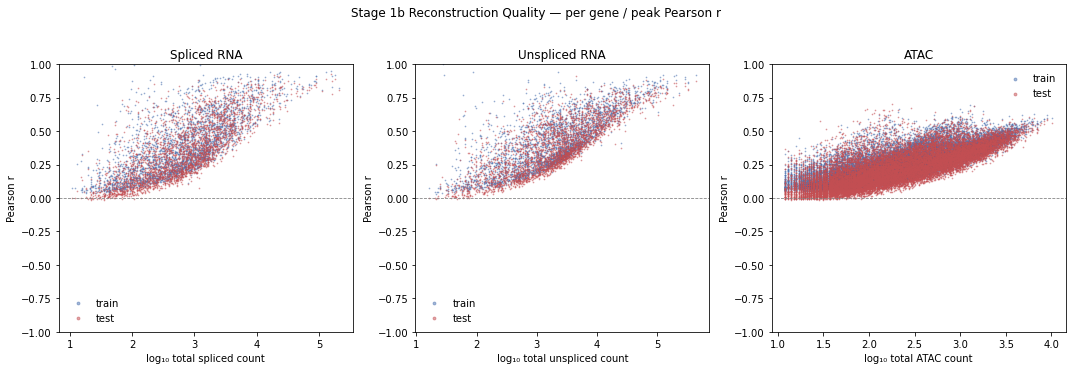

In [6]:
import scipy.sparse

def _dense(x):
    return x.toarray().astype(np.float32) if scipy.sparse.issparse(x) else np.asarray(x, np.float32)

def colwise_pearsonr(obs, rec):
    """Per-column (gene/peak) Pearson r. Returns NaN for zero-variance columns."""
    n = obs.shape[0]
    obs_c = obs - obs.mean(0, keepdims=True)
    rec_c = rec - rec.mean(0, keepdims=True)
    num   = (obs_c * rec_c).sum(0)
    denom = np.sqrt((obs_c ** 2).sum(0) * (rec_c ** 2).sum(0))
    with np.errstate(invalid="ignore"):
        return np.where(denom > 0, num / denom, np.nan)

train_idx = dm.idx["train"]
test_idx  = dm.idx["test"]

# ── Spliced ───────────────────────────────────────────────────────────────────
s_obs  = _dense(dm.adata_r.layers["spliced"])
s_rec  = _dense(dm.adata_r.layers["rec_s"])
log_s  = np.log10(s_obs.sum(0) + 1)
tr_s   = colwise_pearsonr(s_obs[train_idx], s_rec[train_idx])
te_s   = colwise_pearsonr(s_obs[test_idx],  s_rec[test_idx])

# ── Unspliced ─────────────────────────────────────────────────────────────────
u_obs  = _dense(dm.adata_r.layers["unspliced"])
u_rec  = _dense(dm.adata_r.layers["rec_u"])
log_u  = np.log10(u_obs.sum(0) + 1)
tr_u   = colwise_pearsonr(u_obs[train_idx], u_rec[train_idx])
te_u   = colwise_pearsonr(u_obs[test_idx],  u_rec[test_idx])

# ── ATAC: observed = dm.adata_a.X (raw counts), reconstructed = rec_a ────────
a_obs  = _dense(dm.adata_a.X)
a_rec  = _dense(dm.adata_a.layers["rec_a"])
log_a  = np.log10(a_obs.sum(0) + 1)
tr_a   = colwise_pearsonr(a_obs[train_idx], a_rec[train_idx])
te_a   = colwise_pearsonr(a_obs[test_idx],  a_rec[test_idx])

for label, tr, te in [("spliced", tr_s, te_s), ("unspliced", tr_u, te_u), ("ATAC", tr_a, te_a)]:
    print(f"Median Pearson r [{label:9s}]  train: {np.nanmedian(tr):.4f}  test: {np.nanmedian(te):.4f}")

# ── Scatter plots: one point per gene / peak ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panels = [
    (axes[0], log_s, tr_s, te_s, "Spliced RNA",    "log\u2081\u2080 total spliced count"),
    (axes[1], log_u, tr_u, te_u, "Unspliced RNA",  "log\u2081\u2080 total unspliced count"),
    (axes[2], log_a, tr_a, te_a, "ATAC",           "log\u2081\u2080 total ATAC count"),
]
for ax, log_cnt, tr, te, title, xlabel in panels:
    ax.scatter(log_cnt, tr, color="#4C72B0", s=0.5, alpha=0.5, label="train", rasterized=True)
    ax.scatter(log_cnt, te, color="#C44E52", s=0.5, alpha=0.5, label="test",  rasterized=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pearson r")
    ax.set_title(title)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.legend(markerscale=4, frameon=False)

fig.suptitle("Stage 1b Reconstruction Quality — per gene / peak Pearson r", y=1.02)
plt.tight_layout()
plt.show()


## 6. UMAP Visualization

UMAP of the joint latent space, coloured by cell type and by modality.


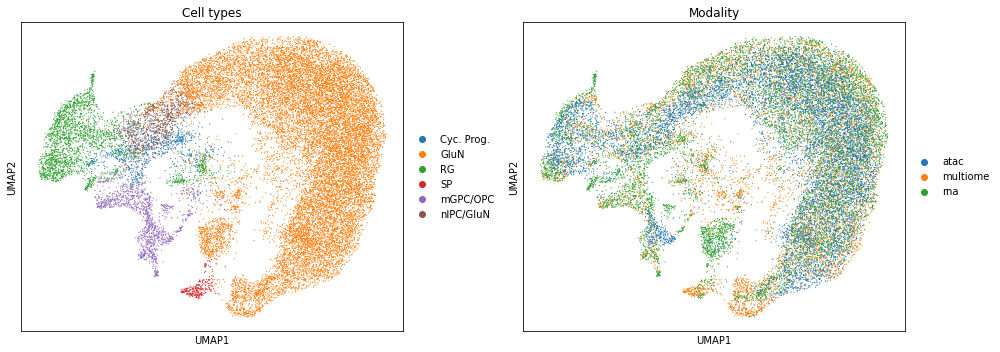

In [7]:
adata_vis = dm.adata_r.copy()
adata_vis.obsm["X_pca"] = dm.adata_r.obsm["latent"]

cluster_df = pd.read_csv(
    f"{DATA_DIR}/cluster_annotation_refined.txt", sep="\t", index_col=0)
adata_vis.obs["ref_clusters"] = cluster_df.iloc[:, 0].reindex(adata_vis.obs_names)

sc.pp.neighbors(adata_vis, use_rep="latent", n_neighbors=30)
sc.tl.umap(adata_vis)
dm.adata_r.obsm["X_umap"] = adata_vis.obsm["X_umap"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata_vis, color="ref_clusters", ax=axes[0],
           title="Cell types", show=False, legend_loc="right margin")
sc.pl.umap(adata_vis, color="modality",    ax=axes[1],
           title="Modality",    show=False, legend_loc="right margin")
plt.tight_layout()
plt.show()


## 7. Stage 2: Smoothed Profile Reconstruction

Stage 2 builds a neighborhood-smoothed DataModule and fine-tunes `DREG_PRE`
to produce denoised profiles (`s_raw`, `u_raw`, `a_raw`) used in Stage 3.


In [8]:
dm_s = run_stage2(dm, RUN_PATH, params, device=device)


RNA dim : 2851 ATAC dim : 20000
Normalized count data: X, spliced, unspliced.
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


DynDataModule_Smooth_MissingModalityPrediction ready.
Running Stage 2 prediction on all cells...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

## 8. Stage 3: Cell State Dynamics

Stage 3 trains `DREG_DYN` to estimate kinetic parameters (splicing rate β,
degradation rate γ) and produces velocity vectors `dsdt` (RNA) and `dadt`
(chromatin).

> **Note**: `DREG_DYN.validation_step` logs `"val_elbo_loss_d"`.
> Both `EarlyStoppingWithWarmup` and `ModelCheckpoint` in `run_stage3` are
> hardcoded to monitor `"val_elbo_loss_d"` to prevent `MisconfigurationException`.


In [9]:
dm_s = run_stage3(dm, dm_s, RUN_PATH, params, device=device)


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


# genes excluded for estimation 119
# genes for estimation 2732.0
Genes for dynamics: 2732 / 2851
Running Stage 3 prediction on all cells...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

dsdt shape : (22843, 2851)
dadt shape : (22843, 20000)


## 9. Save Results

In [ ]:
save_results(dm_s, RUN_PATH)


Results saved to runs/human_brain/


: 

## 10. Streamline Plots

We visualize RNA and chromatin velocities as streamlines on the shared UMAP
embedding.  Because mmVelo handles missing modalities, we have four velocity
fields — one for each (input modality → output velocity) combination.


### 10.1 Load Results and Split by Modality

In [3]:
(adata_r, adata_a,
 adata_r_a2r, adata_r_r2r,
 adata_a_r2a, adata_a_a2a) = load_results_and_split(RUN_PATH, DATA_DIR)


Cells after filtering : 22332
Modality breakdown    : {'rna': 8065, 'atac': 7407, 'multiome': 6860}

atac2rna cells  : 7407
rna2rna  cells  : 14925
rna2atac cells  : 8065
atac2atac cells : 14267


### 10.2 scATAC-seq → ΔRNA velocity

computing velocity graph (using 4/24 cores)


  0%|          | 0/7407 [00:00<?, ?cells/s]

    finished (0:00:28) --> added 
    'dsdt_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'dsdt_umap', embedded velocity vectors (adata.obsm)


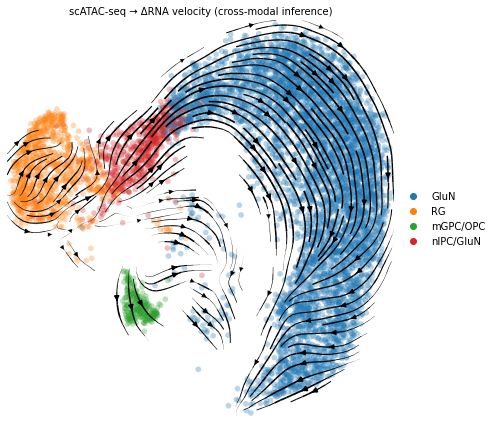

In [12]:
plot_streamline(adata_r_a2r, vkey="dsdt", xkey="s_raw",
                title="scATAC-seq → ΔRNA velocity (cross-modal inference)")


### 10.3 scRNA-seq + Multiome → ΔRNA velocity

computing velocity graph (using 4/24 cores)


  0%|          | 0/14925 [00:00<?, ?cells/s]

    finished (0:01:06) --> added 
    'dsdt_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:02) --> added
    'dsdt_umap', embedded velocity vectors (adata.obsm)


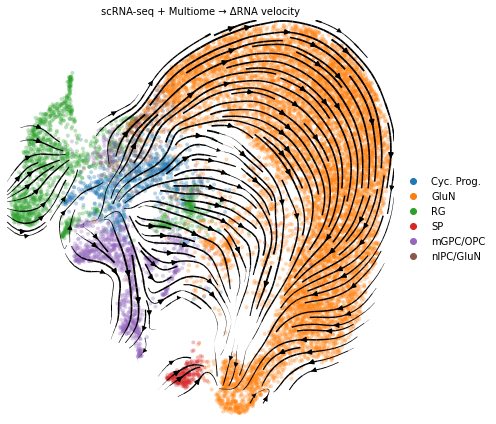

In [13]:
plot_streamline(adata_r_r2r, vkey="dsdt", xkey="s_raw",
                title="scRNA-seq + Multiome → ΔRNA velocity")


### 10.4 scRNA-seq → ΔATAC velocity

computing velocity graph (using 24/24 cores)


  0%|          | 0/8065 [00:00<?, ?cells/s]

    finished (0:01:04) --> added 
    'dadt_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'dadt_umap', embedded velocity vectors (adata.obsm)


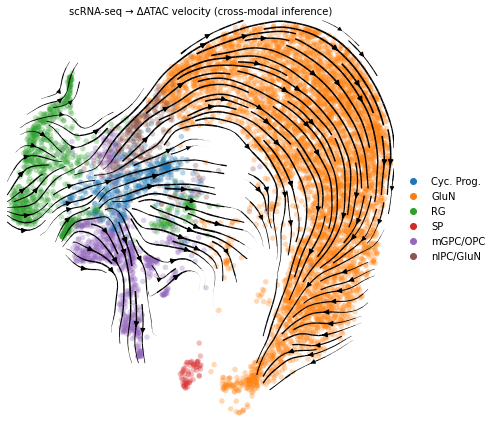

: 

In [ ]:
# scRNA-seq → ΔATAC: 20 000 ATAC peaks make velocity_graph slow.
# Using n_neighbors=15 (vs 30) and n_jobs=-1 (all cores) gives a 4-8× speedup
# with negligible impact on the streamline pattern.
plot_streamline(adata_a_r2a, vkey="dadt", xkey="a_raw",
                title="scRNA-seq → ΔATAC velocity (cross-modal inference)",
                n_neighbors=15, n_jobs=-1)


### 10.5 scATAC-seq + Multiome → ΔATAC velocity


computing velocity graph (using 4/24 cores)


  0%|          | 0/14267 [00:00<?, ?cells/s]

    finished (0:06:02) --> added 
    'dadt_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:02) --> added
    'dadt_umap', embedded velocity vectors (adata.obsm)


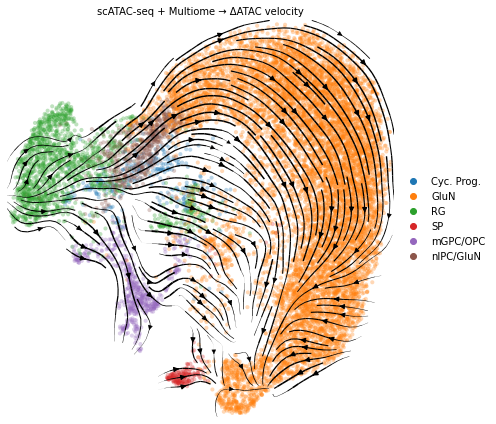

In [4]:
plot_streamline(adata_a_a2a, vkey="dadt", xkey="a_raw",
                title="scATAC-seq + Multiome → ΔATAC velocity")


## 11. Heatmap Analysis (ExN Lineage)

We focus on the **excitatory neuron (ExN) lineage** (`nIPC/GluN` → `GluN`),
ordering cells by diffusion pseudotime and clustering ATAC peaks by cosine
similarity of their chromatin velocity profiles.


### 11.1 Filter to ExN Lineage

In [4]:
adata_r_exn, adata_a_exn = filter_exn_lineage(adata_r, adata_a, DATA_DIR)


ExN lineage cells : 17490
GluN         16640
nIPC/GluN      850

Pseudotime range : [0.0000, 1.0000]


### 11.2 Leiden Clustering of ATAC Peaks

Peaks are treated as observations; cells are features.  A kNN graph (cosine
similarity) is built on the peak-level chromatin velocity matrix and partitioned
with the Leiden algorithm.


Number of ATAC peak clusters: 9


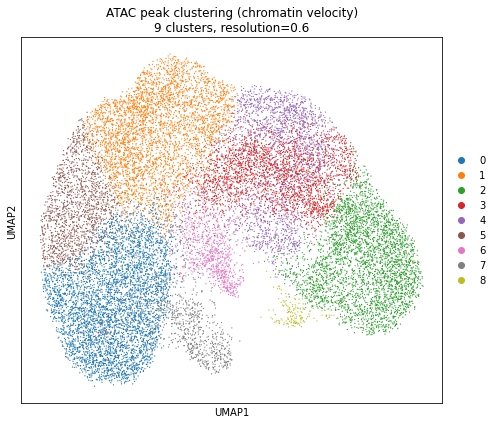

Peak clustering complete.


In [5]:
clusters_sorted, row_colors, make_col_annots = cluster_atac_peaks(
    adata_a_exn, resolution=0.6)


### 11.3 Split ExN Cells by Modality and Trim Pseudotime Range

We compare cross-modal (`rna2atac`) and direct (`atac2atac`) chromatin velocity
over the same pseudotime range.


In [6]:
adata_r2a_exn = adata_a_exn[adata_a_exn.obs["modality"] == "rna", :]
adata_a2a_exn = adata_a_exn[
    adata_a_exn.obs["modality"].isin(["atac", "multiome"]), :]

adata_r2a_exn, adata_a2a_exn = trim_to_overlap(adata_r2a_exn, adata_a2a_exn)
print(f"rna2atac  (ExN, trimmed): {adata_r2a_exn.shape[0]} cells")
print(f"atac2atac (ExN, trimmed): {adata_a2a_exn.shape[0]} cells")


Overlapping pseudotime range: [0.0132, 0.9227]
rna2atac  (ExN, trimmed): 5893 cells
atac2atac (ExN, trimmed): 11471 cells


### 11.4 Chromatin Velocity Heatmap — scRNA-seq → ΔATAC

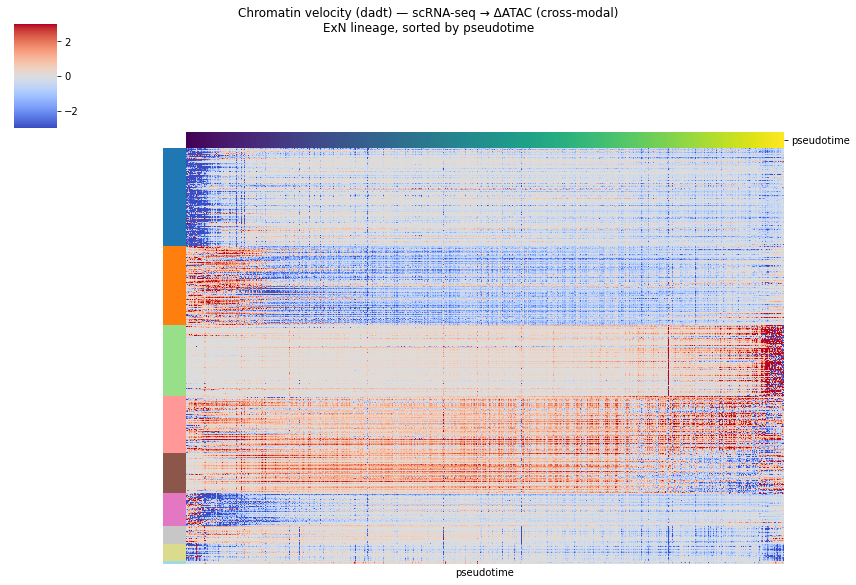

In [7]:
plot_dadt_heatmap(
    adata_r2a_exn, clusters_sorted, row_colors, make_col_annots,
    title="Chromatin velocity (dadt) — scRNA-seq → ΔATAC (cross-modal)\n"
          "ExN lineage, sorted by pseudotime",
)


### 11.5 Chromatin Velocity Heatmap — scATAC-seq + Multiome → ΔATAC

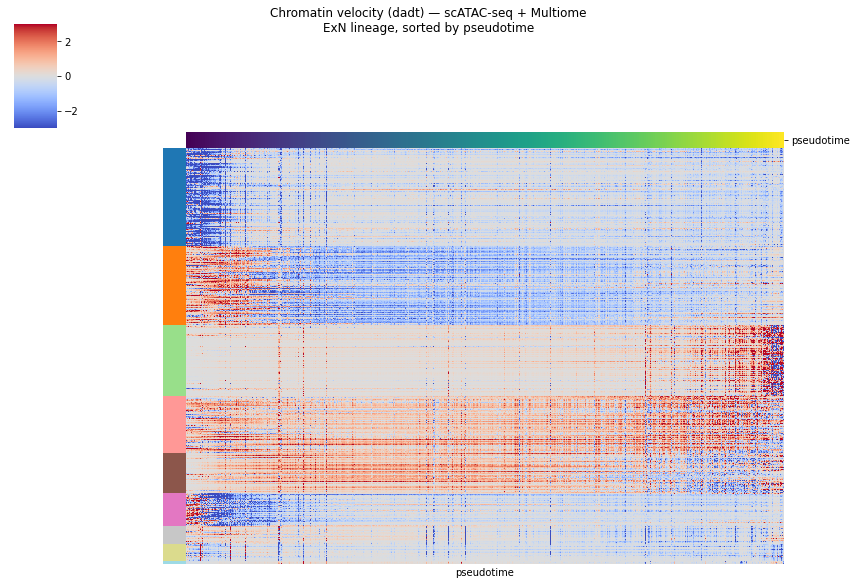

: 

In [ ]:
plot_dadt_heatmap(
    adata_a2a_exn, clusters_sorted, row_colors, make_col_annots,
    title="Chromatin velocity (dadt) — scATAC-seq + Multiome\n"
          "ExN lineage, sorted by pseudotime",
)


### 11.6 Smoothed ATAC Accessibility Heatmap

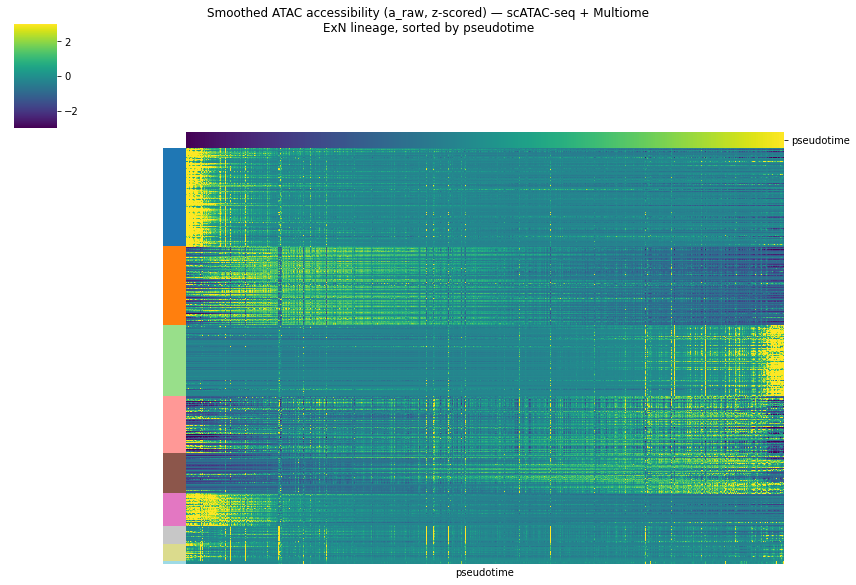

In [7]:
plot_araw_heatmap(
    adata_a2a_exn, clusters_sorted, row_colors, make_col_annots,
    title="Smoothed ATAC accessibility (a_raw, z-scored) — scATAC-seq + Multiome\n"
          "ExN lineage, sorted by pseudotime",
)


## Summary

This tutorial demonstrated mmVelo's **missing modality** inference on the Trevino
et al. (2021) human cortical development dataset:

1. **Joint latent space** — `DREG_PRE` integrates scRNA-seq, scATAC-seq, and
   10x Multiome cells into a shared 10-dimensional latent space.
2. **Cross-modal velocity** — `DREG_DYN` infers `dsdt` for ATAC-only cells and
   `dadt` for RNA-only cells via the shared latent representation.